# Harpy RL Hardware Implementation Datalog Plotting
Author: Arjun Viswanathan \
Date created: 2/18/25 \
Date last modified: 7/25/25

Plotting the commanded vs observed joint positions from the RL policy, in sim and physical world

In [58]:
import pandas as pd
from matplotlib import pyplot as plt 
import matplotlib.image as mpimg
from matplotlib import rcParams
import numpy as np
from itertools import chain 
import os

In [ ]:
run_name = "2025-07-24_22-47-31"
save_folder = f"/home/arjun/Documents/sslab_isaaclab/source/sslab_extensions/simulation/isaacsim_scripts/harpy/plots/{run_name}"
data_folder = f"/home/arjun/Documents/sslab_isaaclab/source/sslab_extensions/simulation/isaacsim_scripts/harpy/data/{run_name}"

os.makedirs(save_folder, exist_ok=True)

In [ ]:
npz_path = os.path.join(data_folder, "sim_data.npz")
npz_data = np.load(npz_path)

sim_dfs = {}
for key in npz_data.files:
    # Convert each array to a DataFrame
    sim_dfs[key] = pd.DataFrame(npz_data[key])

In [60]:
joint_names = [
    'bl_hf_joint', 'br_hf_joint', 'fl_hf_joint', 'fr_hf_joint',
    'bl_hs_joint', 'br_hs_joint', 'fl_hs_joint', 'fr_hs_joint',
    'bl_k_joint', 'br_k_joint', 'fl_k_joint', 'fr_k_joint',
]

# Simulated World

In [ ]:
sim_commanded = sim_dfs['joint_commanded']
sim_observed_pos = sim_dfs['joint_observed']
sim_observed_vel = sim_dfs['joint_velocities']
sim_ang_vel = sim_dfs['ang_vel']
sim_lin_vel = sim_dfs['lin_vel']
sim_orientation = sim_dfs['orientation']

sim_observed_pos_modified = sim_observed_pos.loc[np.repeat(sim_observed_pos.index, 5)].reset_index(drop=True)
sim_observed_vel_modified = sim_observed_vel.loc[np.repeat(sim_observed_vel.index, 5)].reset_index(drop=True)

t = np.arange(0, len(sim_commanded))/200
start = 200
stop = 1000

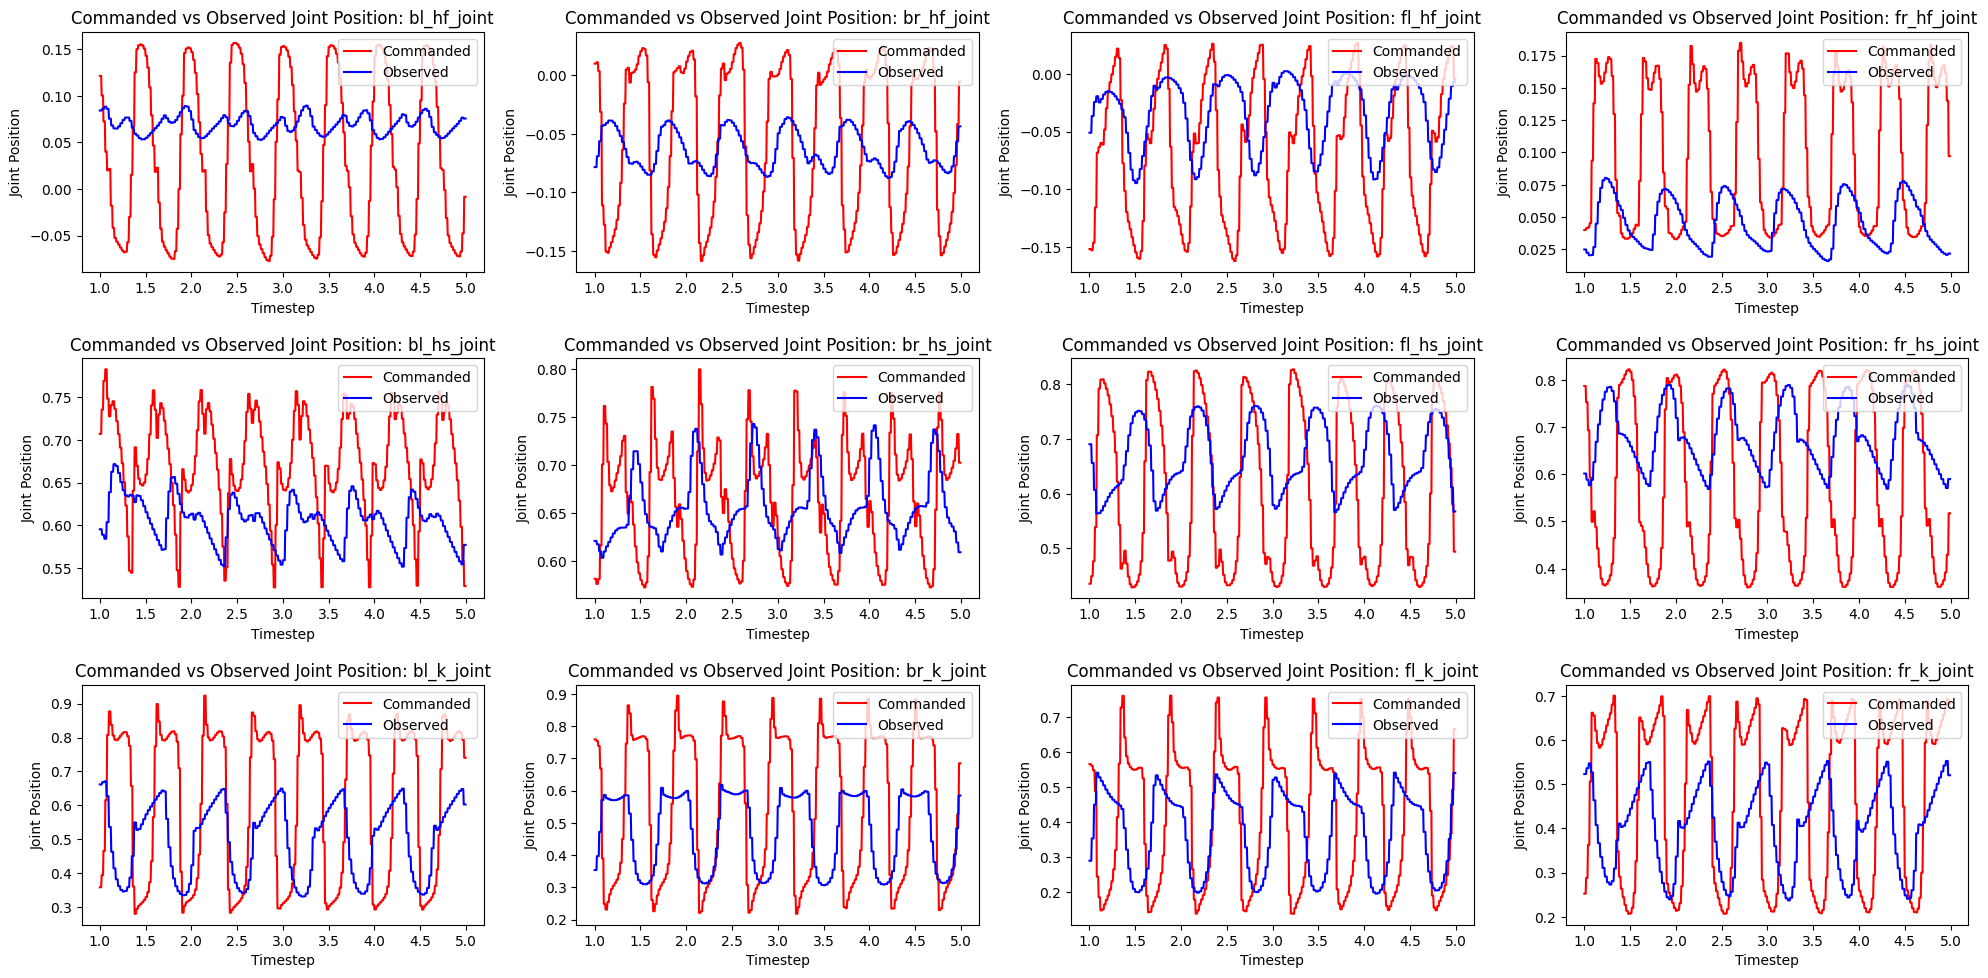

In [ ]:
fig, ax = plt.subplots(3,4, figsize=(20, 10))
i = 0

for r in range(3):
    for c in range(4):
        ax[r,c].plot(t[start:stop], sim_commanded[i][start:stop], c='r')
        ax[r,c].plot(t[start:stop], sim_observed_pos_modified[i][start:stop], c='b')
        ax[r,c].set_xlabel("Timestep")
        ax[r,c].set_ylabel("Joint Position")
        ax[r,c].legend(['Commanded', 'Observed'], loc='upper right')
        ax[r,c].set_title(f"Commanded vs Observed Joint Position: {joint_names[i]}")

        i += 1

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/sim_joint_pos_tracking.png")
plt.show()

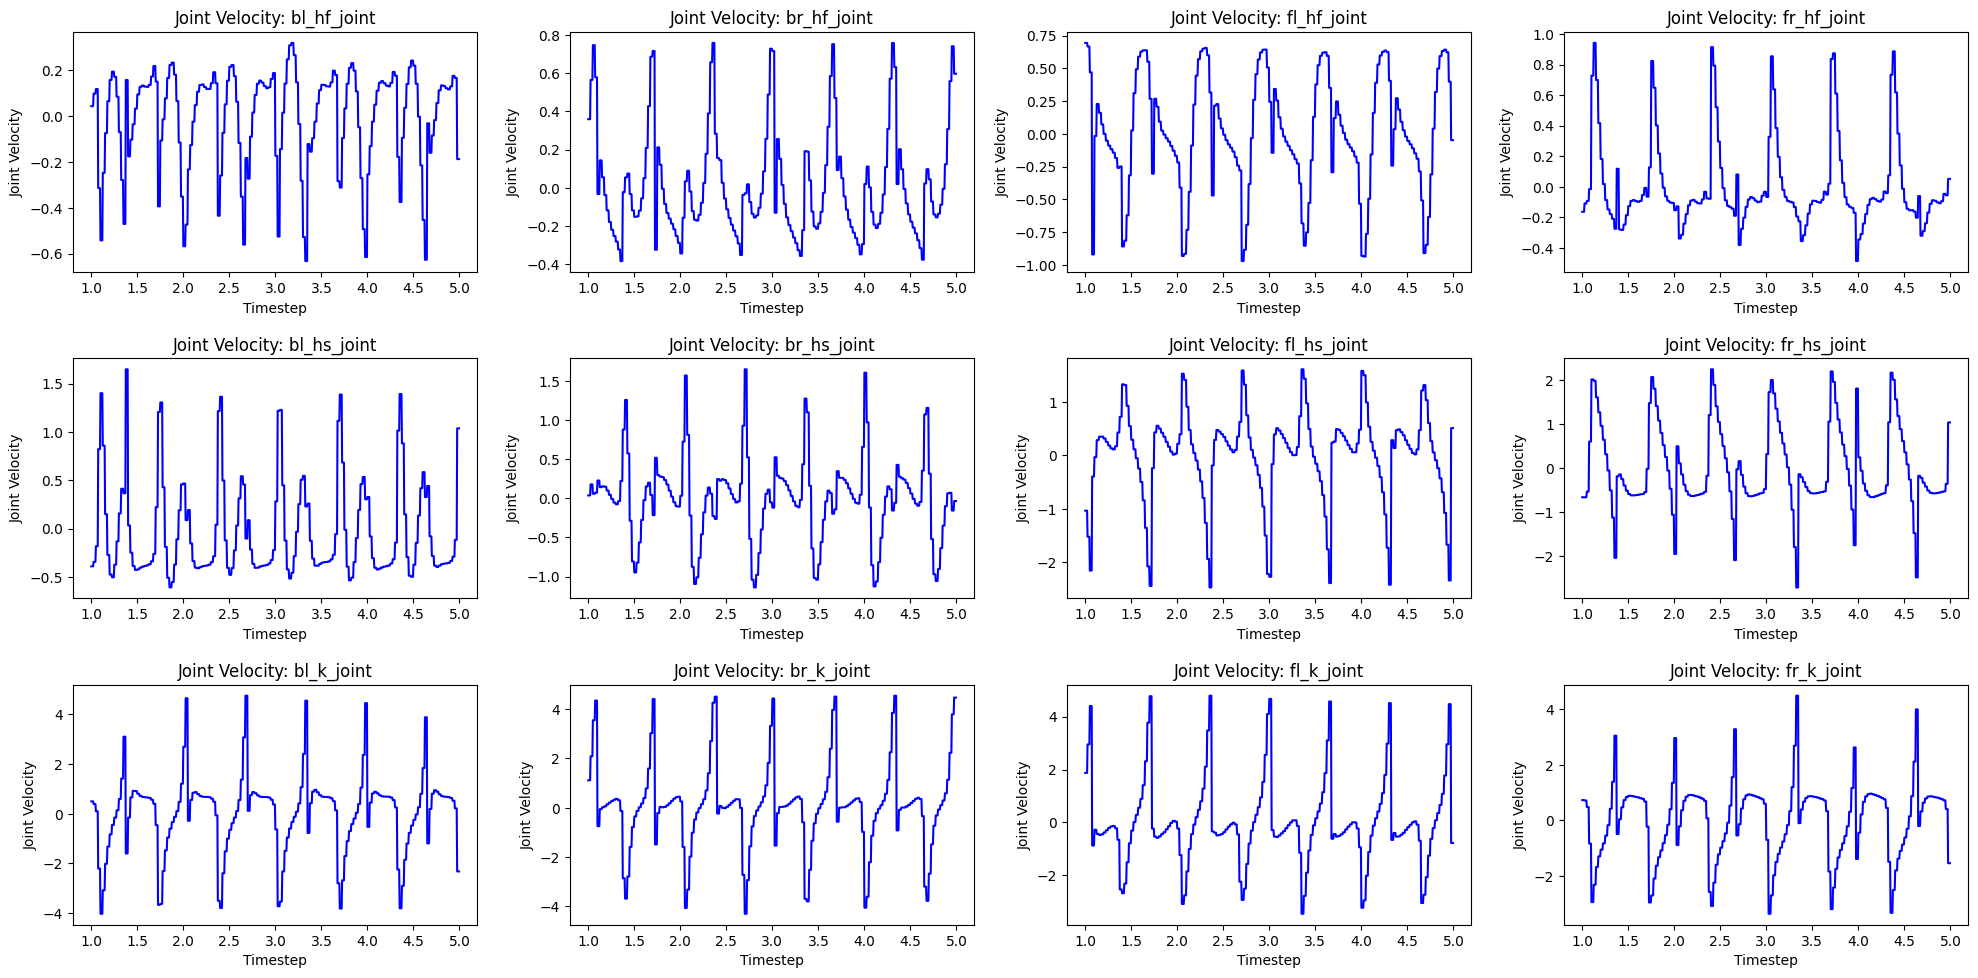

In [ ]:
fig, ax = plt.subplots(3,4, figsize=(20, 10))
i = 0

for r in range(3):
    for c in range(4):
        ax[r,c].plot(t[start:stop], sim_observed_vel_modified[i][start:stop], c='b')
        ax[r,c].set_xlabel("Timestep")
        ax[r,c].set_ylabel("Joint Velocity")
        ax[r,c].set_title(f"Joint Velocity: {joint_names[i]}")

        i += 1

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/sim_joint_vel_tracking.png")
plt.show()

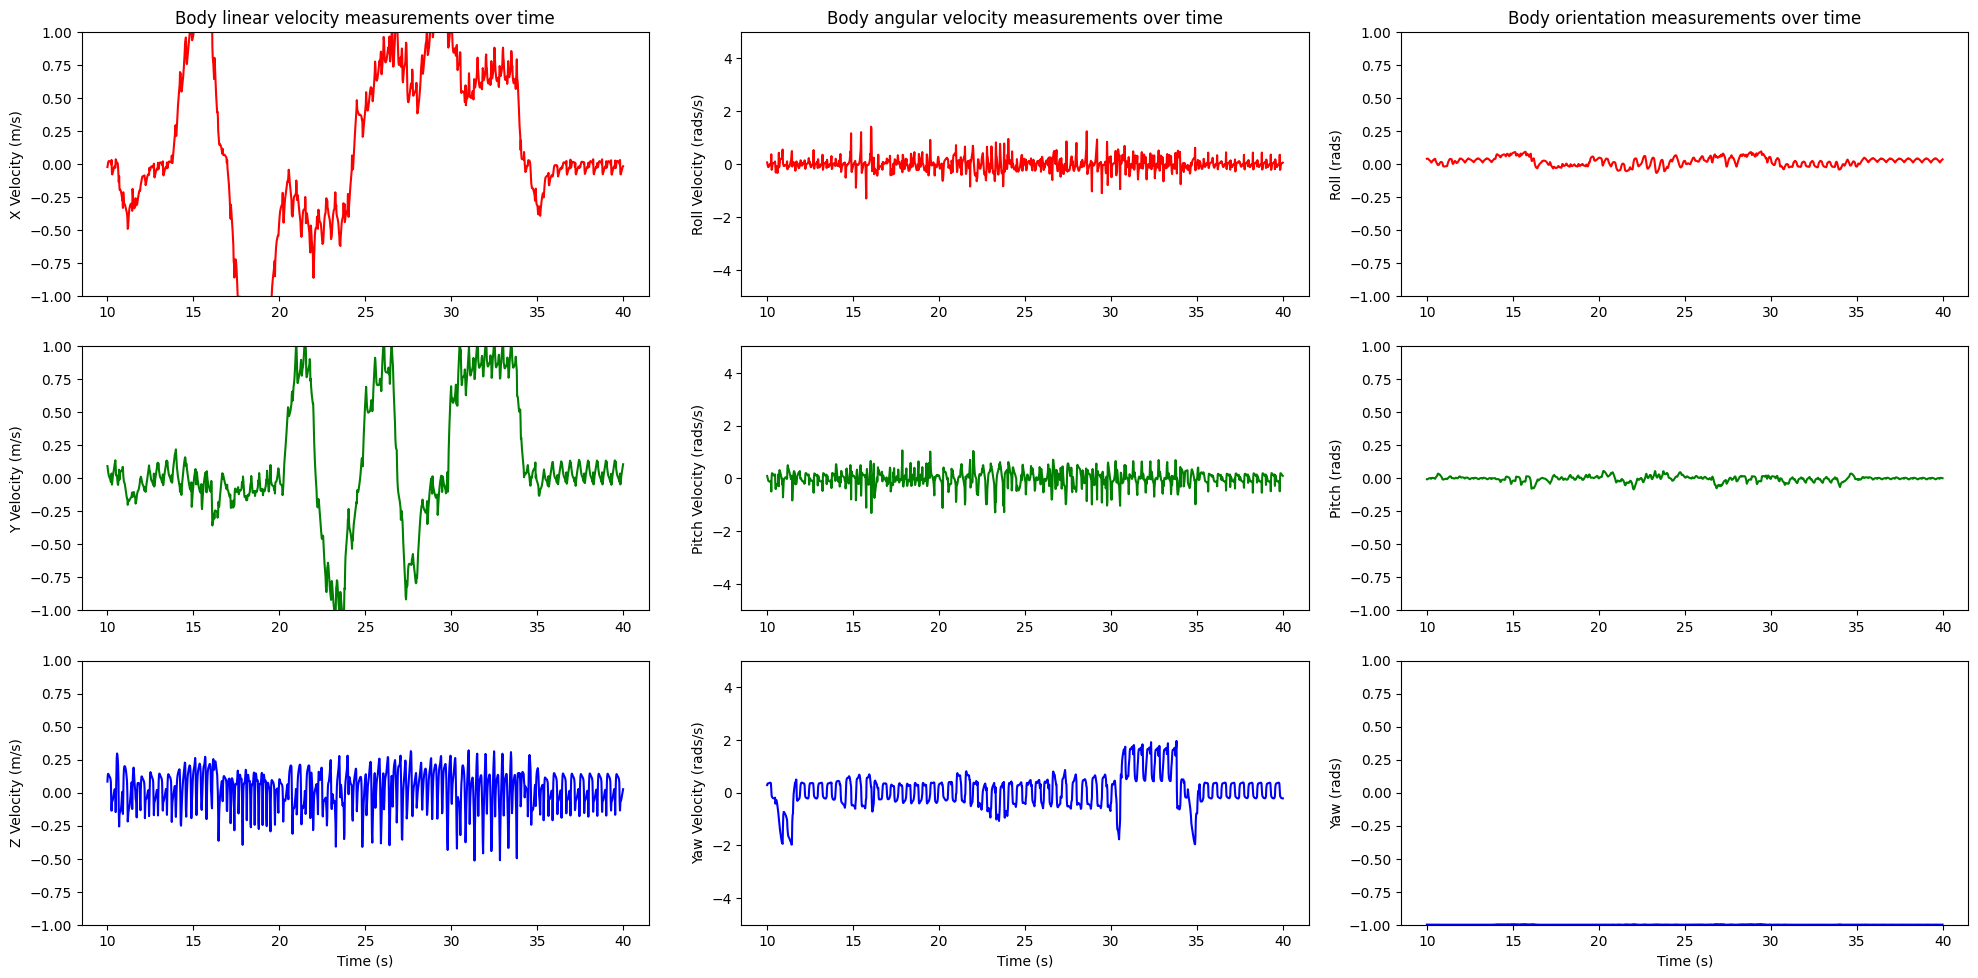

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(20, 10))

t = np.arange(0, len(sim_lin_vel))/50
start = 500
stop = 2000
ax[0,0].plot(t[start:stop], sim_lin_vel[0][start:stop], c='r')
ax[1,0].plot(t[start:stop], sim_lin_vel[1][start:stop], c='g')
ax[2,0].plot(t[start:stop], sim_lin_vel[2][start:stop], c='b')

ax[2,0].set_xlabel("Time (s)")

ax[0,0].set_ylabel("X Velocity (m/s)")
ax[1,0].set_ylabel("Y Velocity (m/s)")
ax[2,0].set_ylabel("Z Velocity (m/s)")

ax[0,0].set_title("Body linear velocity measurements over time")

ax[0,0].set_ylim([-1, 1])
ax[1,0].set_ylim([-1, 1])
ax[2,0].set_ylim([-1, 1])

t = np.arange(0, len(sim_ang_vel))/50
ax[0,1].plot(t[start:stop], sim_ang_vel[0][start:stop], c='r')
ax[1,1].plot(t[start:stop], sim_ang_vel[1][start:stop], c='g')
ax[2,1].plot(t[start:stop], sim_ang_vel[2][start:stop], c='b')

ax[2,1].set_xlabel("Time (s)")

ax[0,1].set_ylabel("Roll Velocity (rads/s)")
ax[1,1].set_ylabel("Pitch Velocity (rads/s)")
ax[2,1].set_ylabel("Yaw Velocity (rads/s)")

ax[0,1].set_title("Body angular velocity measurements over time")

ax[0,1].set_ylim([-5, 5])
ax[1,1].set_ylim([-5, 5])
ax[2,1].set_ylim([-5, 5])

t = np.arange(0, len(sim_orientation))/50
ax[0,2].plot(t[start:stop], sim_orientation[0][start:stop], c='r')
ax[1,2].plot(t[start:stop], sim_orientation[1][start:stop], c='g')
ax[2,2].plot(t[start:stop], sim_orientation[2][start:stop], c='b')

ax[2,2].set_xlabel("Time (s)")

ax[0,2].set_ylabel("Roll (rads)")
ax[1,2].set_ylabel("Pitch (rads)")
ax[2,2].set_ylabel("Yaw (rads)")

ax[0,2].set_title("Body orientation measurements over time")

ax[0,2].set_ylim([-1, 1])
ax[1,2].set_ylim([-1, 1])
ax[2,2].set_ylim([-1, 1])

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/sim_odom.png")
plt.show()

# Physical World

In [53]:
phy_commanded = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_joint_commanded.csv')
phy_observed_pos = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_joint_observed.csv')
phy_observed_vel = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_joint_velocities.csv')
phy_observed_curr = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_joint_currents.csv')

phy_lin_vel = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_lin_vel.csv')
phy_ang_vel = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_ang_vel.csv')
phy_orientation = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/physical_orientation.csv')

phy_time = pd.read_csv('~/Documents/husky-b-rl/husky_beta_isaacsim/data/phy_time.csv')

phy_time["t"] -= phy_time["t"][0]
t = phy_time["t"]

In [54]:
start = 0
stop = len(phy_observed_pos)

bl_hf_joint error mean: 0.2723471458413871, std: 0.848607829348982
br_hf_joint error mean: 0.25743107009392646, std: 0.9062714751983991
fl_hf_joint error mean: 0.27415854868665623, std: 0.8480107061389284
fr_hf_joint error mean: 0.2640157642206482, std: 0.9042694919323448
bl_hs_joint error mean: 0.326291021653202, std: 1.0411071810323307
br_hs_joint error mean: 0.31282243987533126, std: 0.9960946297414792
fl_hs_joint error mean: 0.35046476557897277, std: 1.0908203675940895
fr_hs_joint error mean: 0.3297647448417483, std: 1.0439399187307257
bl_k_joint error mean: 0.3713298475717452, std: 1.119620290828404
br_k_joint error mean: 0.3411684516477929, std: 1.0339570371115459
fl_k_joint error mean: 0.3603673572341574, std: 1.0800000874001503
fr_k_joint error mean: 0.37553581619521836, std: 1.0759147960375912


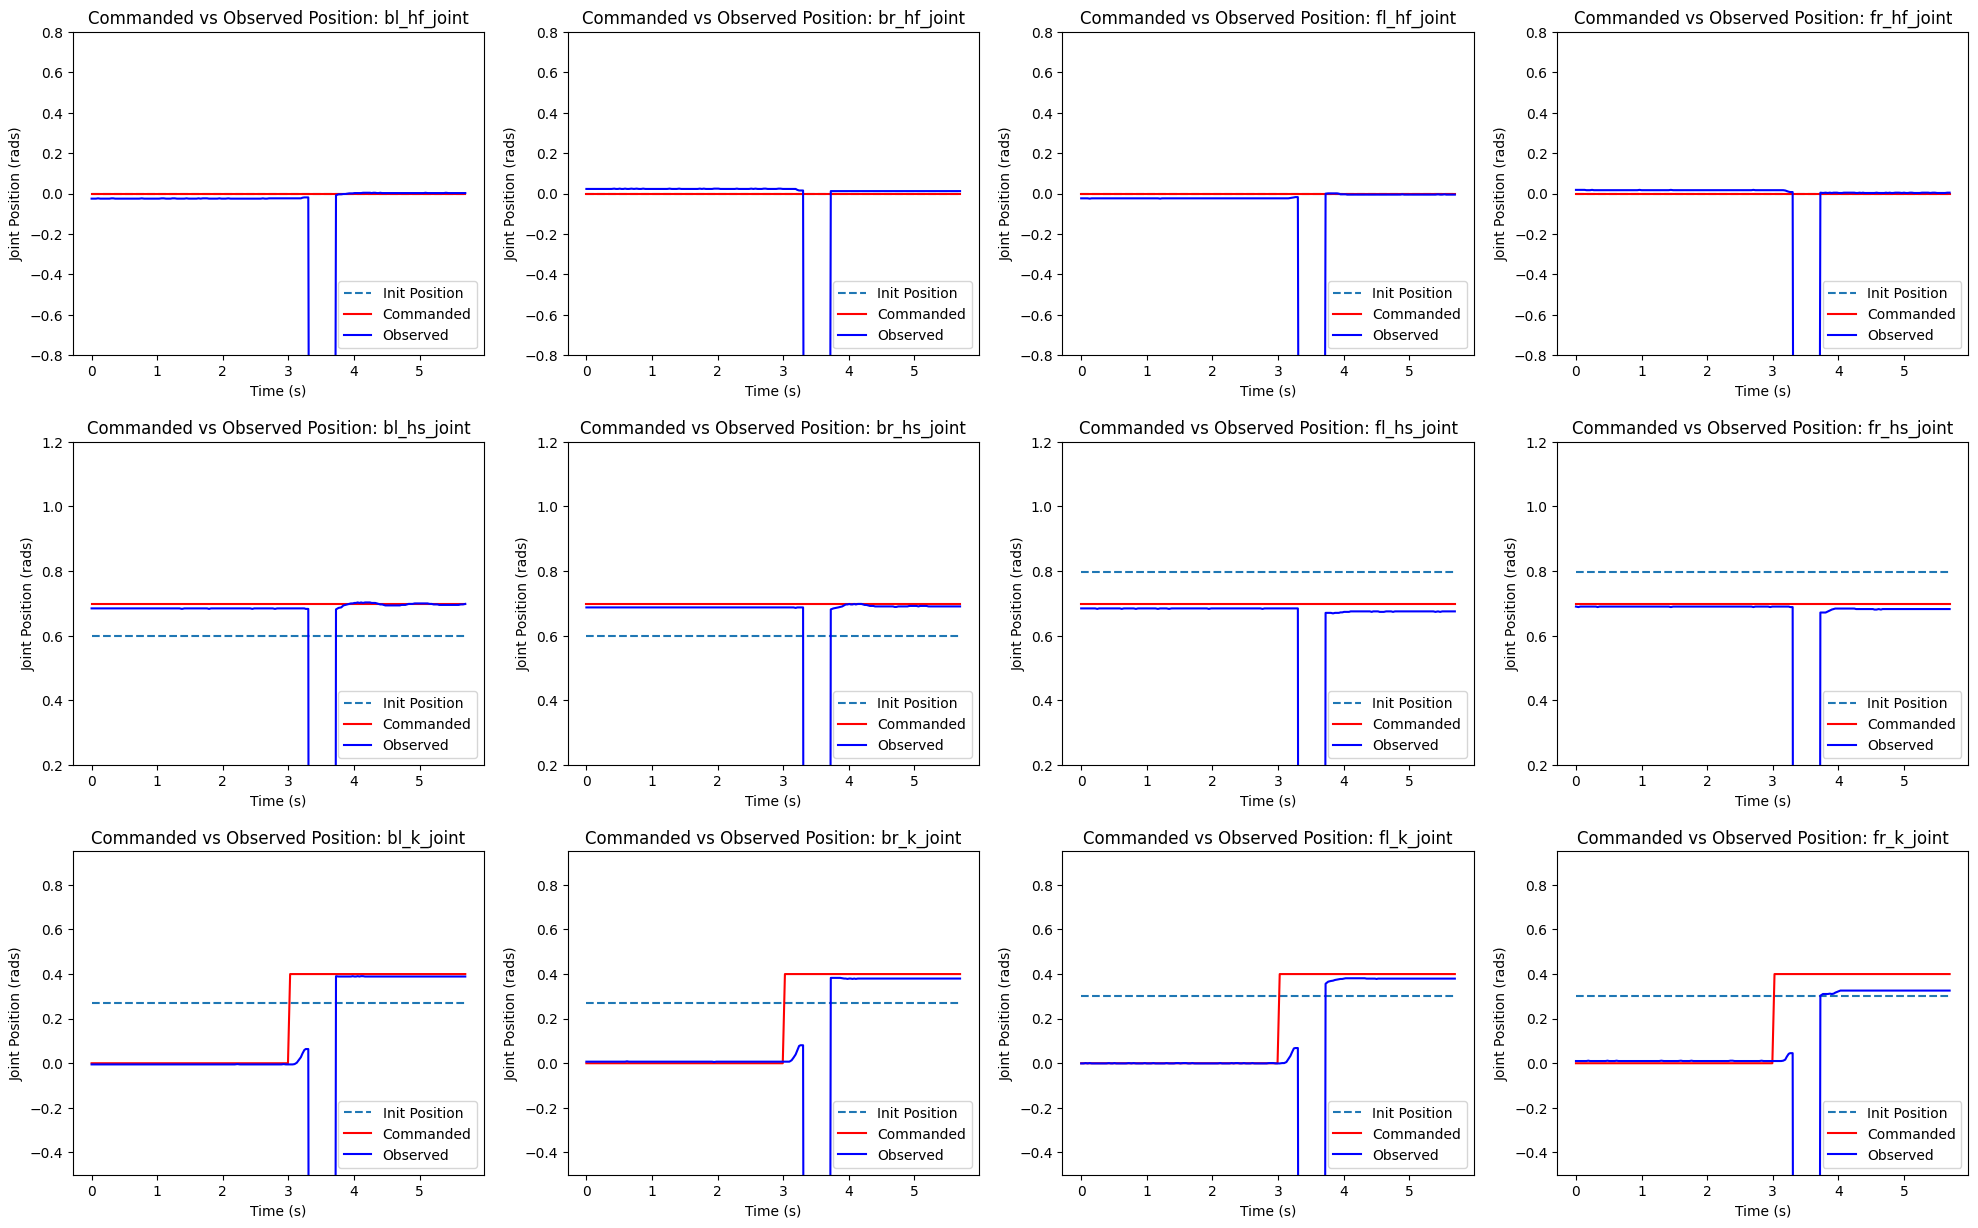

In [56]:
fig, ax = plt.subplots(3,4, figsize=(20, 12.5))
i = 0

for r in range(3):
    for c in range(4):
        if r == 0:
            ax[r,c].set_ylim([-0.8, 0.8])
            ax[r,c].plot(t[start:stop], np.ones(stop - start) * 0.0, "--")
        elif r == 1:
            ax[r,c].set_ylim([0.2, 1.2])
            if c < 2:
                ax[r,c].plot(t[start:stop], np.ones(stop - start) * 0.598132, "--")
            else:
                ax[r,c].plot(t[start:stop], np.ones(stop - start) * 0.798132, "--")
        else:
            ax[r,c].set_ylim([-0.5, 0.95])
            if c < 2:
                ax[r,c].plot(t[start:stop], np.ones(stop - start) * 0.27, "--")
            else:
                ax[r,c].plot(t[start:stop], np.ones(stop - start) * 0.3, "--")

        ax[r,c].plot(t[start:stop], phy_commanded[joint_names[i]][start:stop], c='r')
        ax[r,c].plot(t[start:stop], phy_observed_pos[joint_names[i]][start:stop], c='b')
        ax[r,c].set_xlabel("Time (s)")
        ax[r,c].set_ylabel("Joint Position (rads)")
        ax[r,c].legend(['Init Position', 'Commanded', 'Observed'], loc='lower right')
        ax[r,c].set_title(f"Commanded vs Observed Position: {joint_names[i]}")

        error = phy_commanded[joint_names[i]][start:stop] - phy_observed_pos[joint_names[i]][start:stop]
        print(f"{joint_names[i]} error mean: {np.mean(error, axis=0)}, std: {np.std(error, axis=0)}")

        i += 1

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/phy_joint_pos_tracking.png")
plt.show()

bl_hf_joint error mean: 0.001966427561636965, std: 0.2532666529025769
br_hf_joint error mean: -0.004268586658187573, std: 0.31936688223216586
fl_hf_joint error mean: -0.01683453839352626, std: 0.3200925271688078
fr_hf_joint error mean: -0.007098323881031018, std: 0.3372392701598797
bl_hs_joint error mean: 0.0241726705137813, std: 0.27790033334630665
br_hs_joint error mean: 0.010887294060770549, std: 0.2775233977170389
fl_hs_joint error mean: 0.004556356545256396, std: 0.3026736249992765
fr_hs_joint error mean: 0.0016306960267233447, std: 0.4056201484113952
bl_k_joint error mean: -0.007529978711634257, std: 0.33235328672582476
br_k_joint error mean: 0.007482017063789455, std: 0.6024518771786729
fl_k_joint error mean: -0.00047961647844804435, std: 0.5445577830969939
fr_k_joint error mean: -0.012230220200425067, std: 0.4341296845898975


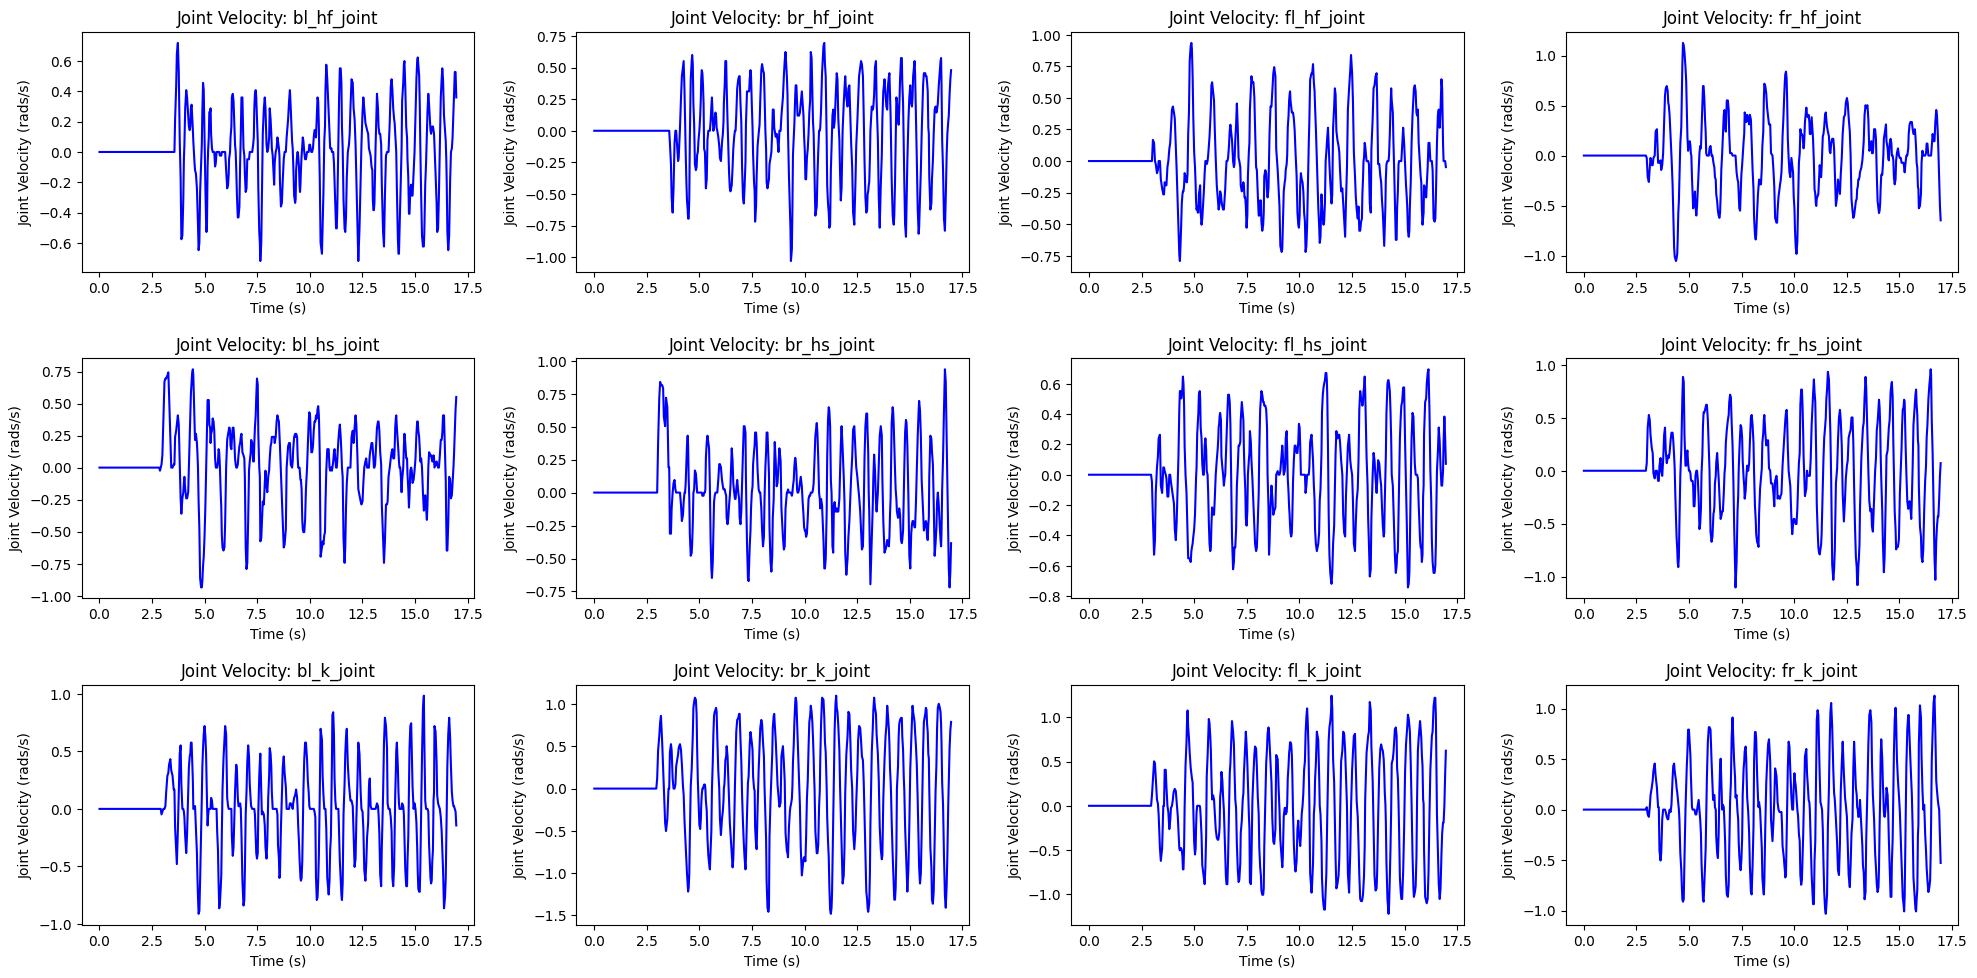

In [175]:
fig, ax = plt.subplots(3,4, figsize=(20, 10))
i = 0

for r in range(3):
    for c in range(4):
        ax[r,c].plot(t[start:stop], phy_observed_vel[joint_names[i]][start:stop], c='b')
        ax[r,c].set_xlabel("Time (s)")
        ax[r,c].set_ylabel("Joint Velocity (rads/s)")
        ax[r,c].set_title(f"Joint Velocity: {joint_names[i]}")

        error = phy_observed_vel[joint_names[i]][start:stop]
        print(f"{joint_names[i]} error mean: {np.mean(error, axis=0)}, std: {np.std(error, axis=0)}")

        i += 1

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/phy_joint_vel_tracking.png")
plt.show()

bl_hf_joint error mean: 0.0743957435897436, std: 0.12706633506361295
br_hf_joint error mean: -0.15200569230769234, std: 0.2591218502497009
fl_hf_joint error mean: 0.06756728205128207, std: 0.11957745149461119
fr_hf_joint error mean: -0.07345769230769231, std: 0.13356942583639528
bl_hs_joint error mean: 0.03359051282051282, std: 0.09037117272241296
br_hs_joint error mean: 0.0816242564102564, std: 0.13894412092760353
fl_hs_joint error mean: 0.06901574358974359, std: 0.11723697085920441
fr_hs_joint error mean: 0.10179235897435895, std: 0.18811743212228205
bl_k_joint error mean: 0.17507071794871795, std: 0.3120847520630474
br_k_joint error mean: 0.08648005128205129, std: 0.2189990854646575
fl_k_joint error mean: 0.1956388717948718, std: 0.4945430766374242
fr_k_joint error mean: 0.5090307692307693, std: 0.9005304923398025


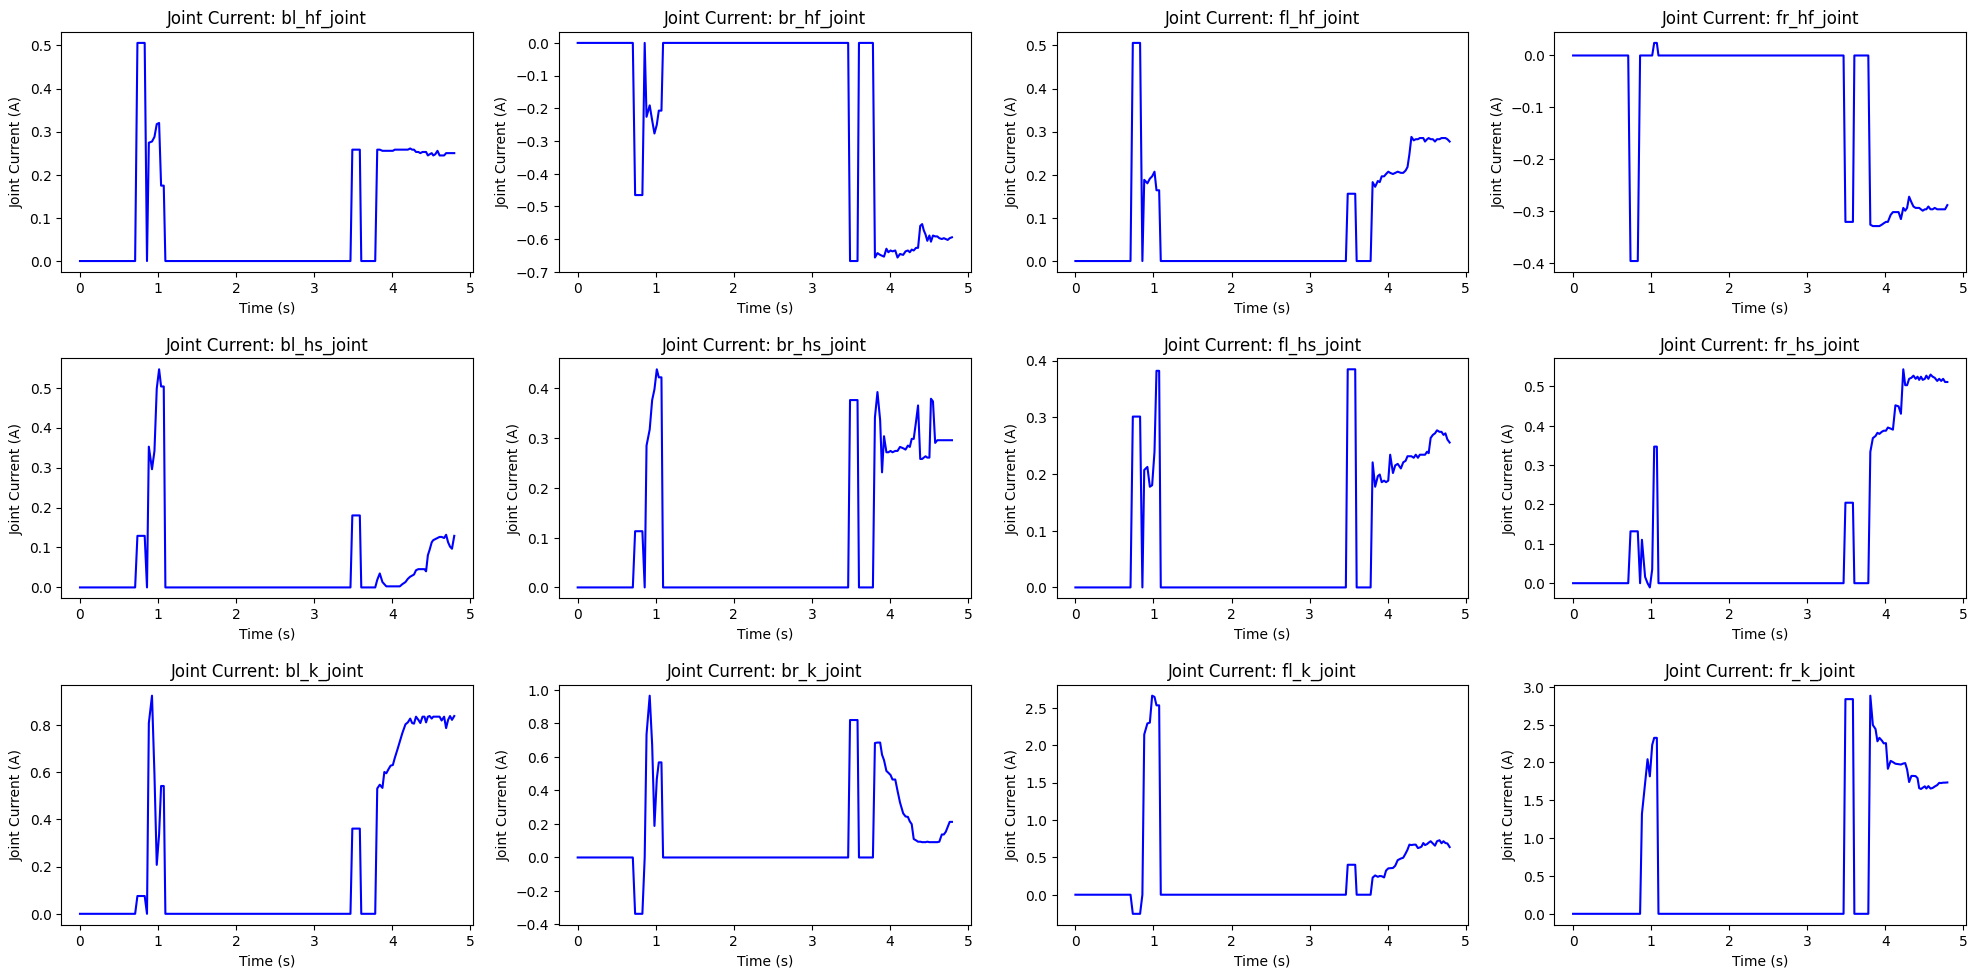

In [37]:
fig, ax = plt.subplots(3,4, figsize=(20, 10))
i = 0

for r in range(3):
    for c in range(4):
        ax[r,c].plot(t[start:stop], phy_observed_curr[joint_names[i]][start:stop], c='b')
        ax[r,c].set_xlabel("Time (s)")
        ax[r,c].set_ylabel("Joint Current (A)")
        ax[r,c].set_title(f"Joint Current: {joint_names[i]}")

        error = phy_observed_curr[joint_names[i]][start:stop]
        print(f"{joint_names[i]} error mean: {np.mean(error, axis=0)}, std: {np.std(error, axis=0)}")

        i += 1

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/phy_joint_curr_tracking.png")
plt.show()

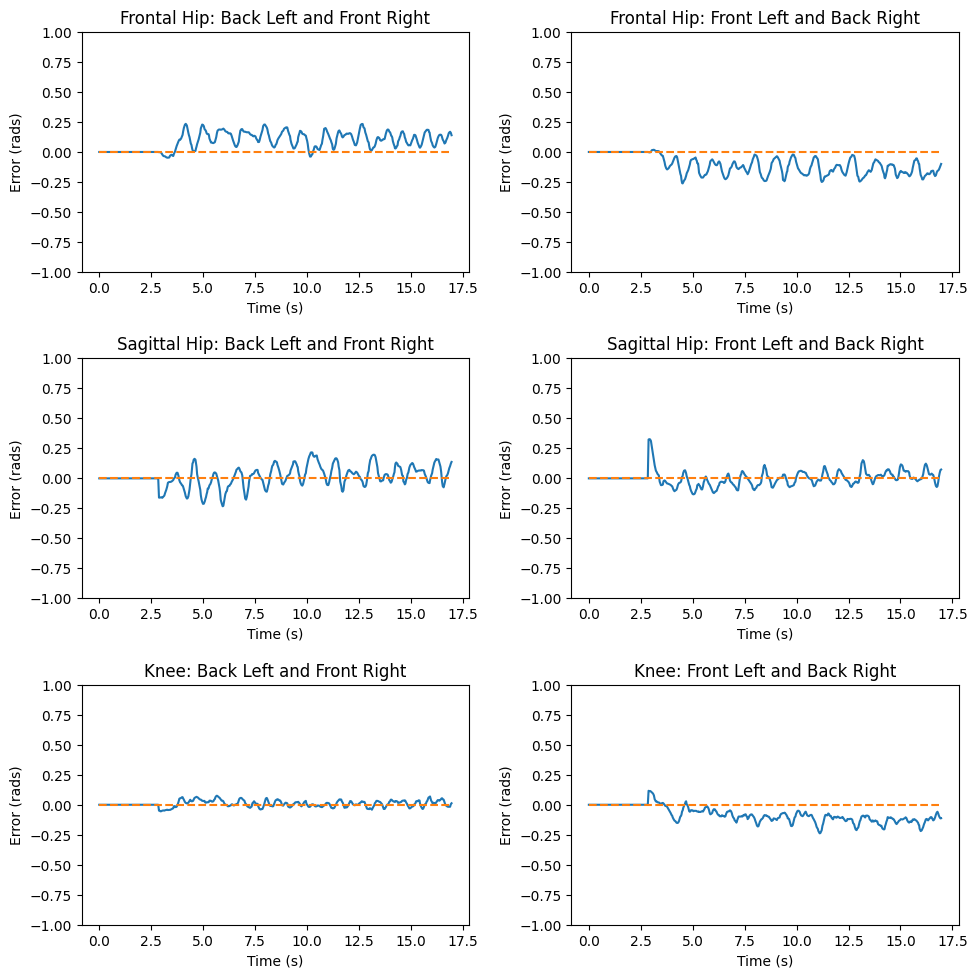

In [177]:
fig, ax = plt.subplots(3,2, figsize=(10, 10))

ax[0,0].plot(t[start:stop], phy_observed_pos['bl_hf_joint'][start:stop] + phy_observed_pos['fr_hf_joint'][start:stop])
ax[0,1].plot(t[start:stop], phy_observed_pos['fl_hf_joint'][start:stop] + phy_observed_pos['br_hf_joint'][start:stop])
ax[0,0].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[0,1].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[0,0].set_ylim([-1.0, 1.0])
ax[0,1].set_ylim([-1.0, 1.0])
ax[0,0].set_xlabel('Time (s)')
ax[0,0].set_ylabel('Error (rads)')
ax[0,1].set_xlabel('Time (s)')
ax[0,1].set_ylabel('Error (rads)')
ax[0,0].set_title('Frontal Hip: Back Left and Front Right')
ax[0,1].set_title('Frontal Hip: Front Left and Back Right')

ax[1,0].plot(t[start:stop], phy_observed_pos['bl_hs_joint'][start:stop] - phy_observed_pos['fr_hs_joint'][start:stop])
ax[1,1].plot(t[start:stop], phy_observed_pos['fl_hs_joint'][start:stop] - phy_observed_pos['br_hs_joint'][start:stop])
ax[1,0].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[1,1].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[1,0].set_ylim([-1.0, 1.0])
ax[1,1].set_ylim([-1.0, 1.0])
ax[1,0].set_xlabel('Time (s)')
ax[1,0].set_ylabel('Error (rads)')
ax[1,1].set_xlabel('Time (s)')
ax[1,1].set_ylabel('Error (rads)')
ax[1,0].set_title('Sagittal Hip: Back Left and Front Right')
ax[1,1].set_title('Sagittal Hip: Front Left and Back Right')

ax[2,0].plot(t[start:stop], phy_observed_pos['bl_k_joint'][start:stop] - phy_observed_pos['fr_k_joint'][start:stop])
ax[2,1].plot(t[start:stop], phy_observed_pos['fl_k_joint'][start:stop] - phy_observed_pos['br_k_joint'][start:stop])
ax[2,0].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[2,1].plot(t[start:stop], np.zeros(len(t[start:stop])), linestyle="--")
ax[2,0].set_ylim([-1.0, 1.0])
ax[2,1].set_ylim([-1.0, 1.0])
ax[2,0].set_xlabel('Time (s)')
ax[2,0].set_ylabel('Error (rads)')
ax[2,1].set_xlabel('Time (s)')
ax[2,1].set_ylabel('Error (rads)')
ax[2,0].set_title('Knee: Back Left and Front Right')
ax[2,1].set_title('Knee: Front Left and Back Right')

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/phy_joint_sync_errors.png")
plt.show()

Linear velocity mean: 0.0011987714712998578, std: 0.10332884915051833
Linear velocity mean: -0.0009879290716244432, std: 0.09385903272058899
Linear velocity mean: -0.0032073826725137547, std: 0.16059659379349198
Linear velocity mean: 0.003647623100022525, std: 0.3065148470426828
Linear velocity mean: 0.0004466592677719053, std: 0.1790627338981202
Linear velocity mean: 0.0023725178424145077, std: 0.44334064704942294
Linear velocity mean: 0.014110265451999292, std: 0.05011005081804187
Linear velocity mean: 0.05680732917628752, std: 0.02728507282354637
Linear velocity mean: -0.05802264966537013, std: 0.14819947938477446


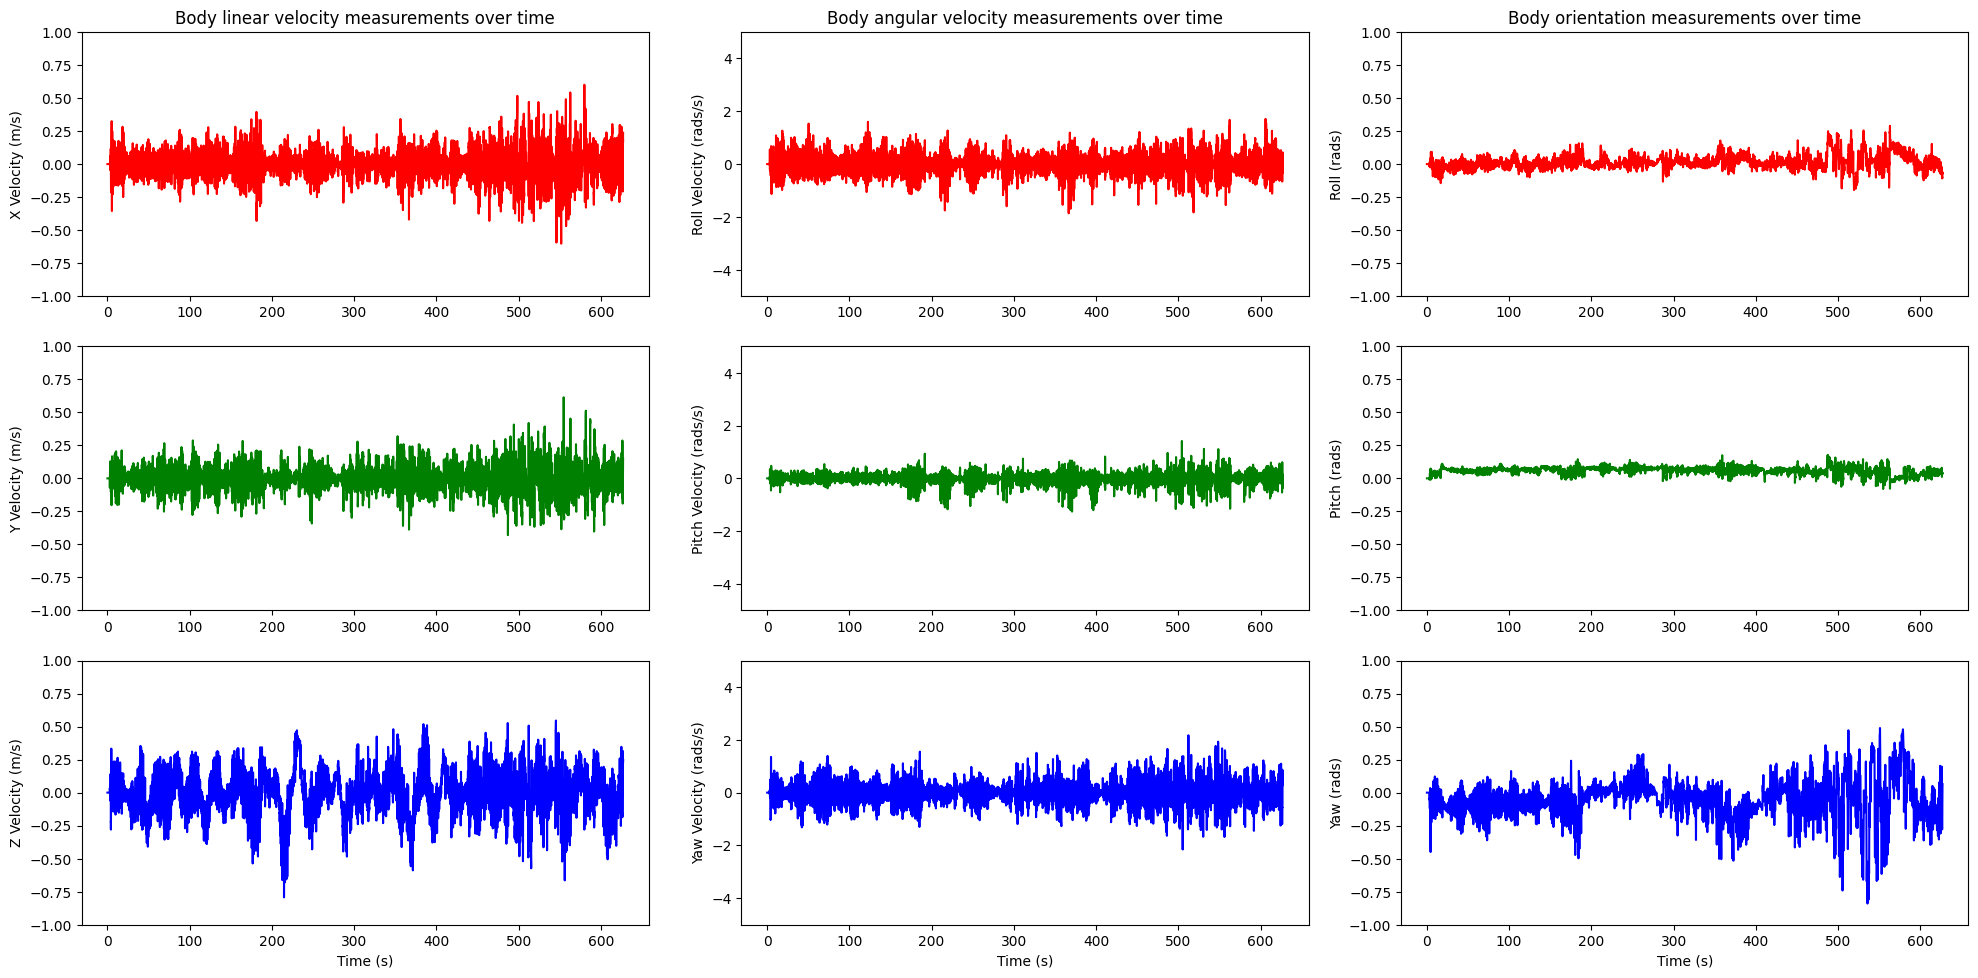

In [178]:
fig, ax = plt.subplots(3,3, figsize=(20, 10))

ax[0,0].plot(t, phy_lin_vel['vx'], c='r')
ax[1,0].plot(t, phy_lin_vel['vy'], c='g')
ax[2,0].plot(t, phy_lin_vel['vz'], c='b')

print(f"Linear velocity mean: {np.mean(phy_lin_vel['vx'], axis=0)}, std: {np.std(phy_lin_vel['vx'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_lin_vel['vy'], axis=0)}, std: {np.std(phy_lin_vel['vy'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_lin_vel['vz'], axis=0)}, std: {np.std(phy_lin_vel['vz'], axis=0)}")

ax[2,0].set_xlabel("Time (s)")

ax[0,0].set_ylabel("X Velocity (m/s)")
ax[1,0].set_ylabel("Y Velocity (m/s)")
ax[2,0].set_ylabel("Z Velocity (m/s)")

ax[0,0].set_title("Body linear velocity measurements over time")

ax[0,0].set_ylim([-1, 1])
ax[1,0].set_ylim([-1, 1])
ax[2,0].set_ylim([-1, 1])

ax[0,1].plot(t, phy_ang_vel['wx'], c='r')
ax[1,1].plot(t, phy_ang_vel['wy'], c='g')
ax[2,1].plot(t, phy_ang_vel['wz'], c='b')

print(f"Linear velocity mean: {np.mean(phy_ang_vel['wx'], axis=0)}, std: {np.std(phy_ang_vel['wx'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_ang_vel['wy'], axis=0)}, std: {np.std(phy_ang_vel['wy'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_ang_vel['wz'], axis=0)}, std: {np.std(phy_ang_vel['wz'], axis=0)}")

ax[2,1].set_xlabel("Time (s)")

ax[0,1].set_ylabel("Roll Velocity (rads/s)")
ax[1,1].set_ylabel("Pitch Velocity (rads/s)")
ax[2,1].set_ylabel("Yaw Velocity (rads/s)")

ax[0,1].set_title("Body angular velocity measurements over time")

ax[0,1].set_ylim([-5, 5])
ax[1,1].set_ylim([-5, 5])
ax[2,1].set_ylim([-5, 5])

ax[0,2].plot(t, phy_orientation['roll'], c='r')
ax[1,2].plot(t, phy_orientation['pitch'], c='g')
ax[2,2].plot(t, phy_orientation['yaw'], c='b')

print(f"Linear velocity mean: {np.mean(phy_orientation['roll'], axis=0)}, std: {np.std(phy_orientation['roll'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_orientation['pitch'], axis=0)}, std: {np.std(phy_orientation['pitch'], axis=0)}")
print(f"Linear velocity mean: {np.mean(phy_orientation['yaw'], axis=0)}, std: {np.std(phy_orientation['yaw'], axis=0)}")

ax[2,2].set_xlabel("Time (s)")

ax[0,2].set_ylabel("Roll (rads)")
ax[1,2].set_ylabel("Pitch (rads)")
ax[2,2].set_ylabel("Yaw (rads)")

ax[0,2].set_title("Body orientation measurements over time")

ax[0,2].set_ylim([-1, 1])
ax[1,2].set_ylim([-1, 1])
ax[2,2].set_ylim([-1, 1])

plt.tight_layout(pad=1.5)
plt.savefig(f"{save_folder}/phy_odom.png")
plt.show()